In [49]:
import sqlite3

# Connect to SQLite
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

# Create table (if it doesn't exist)
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

# Insert sample data with at least 10 unique products
sales_data = [
    ("Product A", 10, 5.0),
    ("Product B", 15, 7.5),
    ("Product C", 8, 12.0),
    ("Product D", 20, 10.0),
    ("Product E", 5, 4.0),
    ("Product F", 18, 15.0),
    ("Product G", 12, 6.5),
    ("Product H", 25, 8.0),
    ("Product I", 30, 9.5),
    ("Product J", 22, 11.0),
    ("Product A", 5, 5.0),
    ("Product B", 10, 7.5),
    ("Product C", 12, 12.0),
    ("Product D", 8, 10.0),
    ("Product E", 14, 4.0)
]

cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sales_data)

# Save changes and close connection
conn.commit()
conn.close()

print("✅ Database updated with 10+ products!")

✅ Database updated with 10+ products!


In [51]:
import sqlite3
import pandas as pd

# Connect to SQLite database
conn = sqlite3.connect("sales_data.db")

# SQL query to get updated total quantity and revenue per product
query = """
SELECT product, SUM(quantity) AS total_qty, SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""

# Load data into pandas DataFrame
df = pd.read_sql_query(query, conn)

# Print results
print("📊 Updated Sales Summary:")
print(df)

# Close connection
conn.close()

📊 Updated Sales Summary:
     product  total_qty  revenue
0  Product A         75    375.0
1  Product B        125    937.5
2  Product C        100   1200.0
3  Product D         84    840.0
4  Product E         57    228.0
5  Product F         54    810.0
6  Product G         36    234.0
7  Product H         75    600.0
8  Product I         90    855.0
9  Product J         66    726.0


<Figure size 1200x600 with 0 Axes>

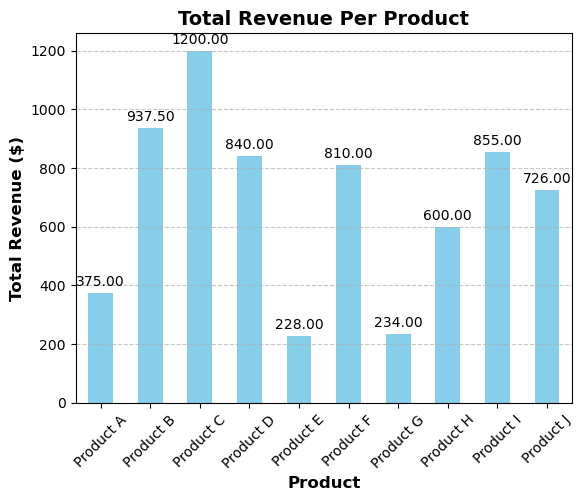

In [55]:
import matplotlib.pyplot as plt

# Set a larger figure size to accommodate more products
plt.figure(figsize=(12, 6))

# Plot bar chart with better spacing
bar_chart = df.plot(kind='bar', x='product', y='revenue', legend=False, color=['skyblue'])

# Add labels to bars with adjusted positioning
for index, value in enumerate(df["revenue"]):
    plt.text(index, value + (max(df["revenue"]) * 0.02), f"{value:.2f}", ha='center', fontsize=10, color="black")

# Set axis labels & title with improved formatting
plt.xlabel("Product", fontsize=12, fontweight='bold')
plt.ylabel("Total Revenue ($)", fontsize=12, fontweight='bold')
plt.title("Total Revenue Per Product", fontsize=14, fontweight='bold')

# 🔹 Fix congested x-axis labels:
plt.xticks(rotation=45, fontsize=10)  # Rotate labels for better visibility

# Add grid lines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save the chart if needed
plt.savefig("sales_chart_fixed.png")

# Show the plot
plt.show()

In [59]:
import sqlite3
import pandas as pd

# Connect to SQLite database
conn = sqlite3.connect("sales_data.db")

# Run the SQL query to get total quantity sold per product
query_quantity = """
SELECT product, SUM(quantity) AS total_qty
FROM sales
GROUP BY product
"""

df_qty = pd.read_sql_query(query_quantity, conn)

# Print the data to verify
print("📊 Total Quantity Sold Per Product:")
print(df_qty)

conn.close()

📊 Total Quantity Sold Per Product:
     product  total_qty
0  Product A         75
1  Product B        125
2  Product C        100
3  Product D         84
4  Product E         57
5  Product F         54
6  Product G         36
7  Product H         75
8  Product I         90
9  Product J         66


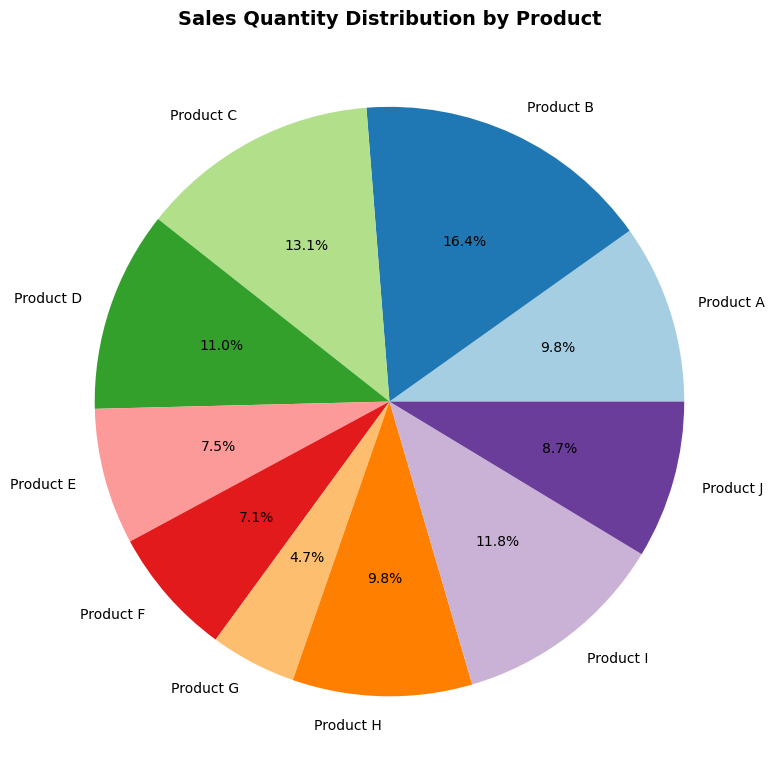

In [61]:
import matplotlib.pyplot as plt

# Set figure size
plt.figure(figsize=(8, 8))

# Create a pie chart
plt.pie(df_qty["total_qty"], labels=df_qty["product"], autopct="%1.1f%%", colors=plt.cm.Paired.colors)

# Set title
plt.title("Sales Quantity Distribution by Product", fontsize=14, fontweight='bold')

# Improve layout
plt.tight_layout()

# Save the chart if needed
plt.savefig("sales_quantity_pie_chart.png")

# Show the plot
plt.show()